In [1]:
from model import *
import numpy as np
import random
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score, f1_score, adjusted_rand_score
from scipy.optimize import linear_sum_assignment
import pandas as pd

## Find MAP

## Generate data


In [2]:
def generate_mixture_data(
    n_assessors=100,
    n_items=10,
    C=3,
    seed=1,
    gap=1.2,
    sigma=0.8,
    tau=None,
    n_blocks=None,
    n_blocks_range=(3, 6),
    min_block_size=1,
):
    rng = np.random.default_rng(seed)

    if n_items < 1:
        raise ValueError("n_items must be >= 1")
    if C < 1:
        raise ValueError("C must be >= 1")
    if min_block_size < 1:
        raise ValueError("min_block_size must be >= 1")

    # ---- tau ----
    if tau is None:
        tau = np.ones(C) / C
    else:
        tau = np.asarray(tau, dtype=float)
        if tau.shape != (C,):
            raise ValueError(f"tau must have length C={C}")
        if tau.sum() <= 0:
            raise ValueError("tau must sum to a positive value")
        tau = tau / tau.sum()

    def choose_k():
        if n_blocks is not None:
            k = int(n_blocks)
        else:
            lo, hi = n_blocks_range
            if lo < 1 or hi < lo:
                raise ValueError("n_blocks_range must be (low>=1, high>=low)")
            k = int(rng.integers(lo, hi + 1))

        # cap so we can give each block at least min_block_size items
        k_max = n_items // min_block_size
        if k_max < 1:
            # min_block_size > n_items, so only possible is 1 block
            return 1
        return max(1, min(k, k_max))

    def sizes_no_empty(total, k, min_part):
        """
        Return k sizes summing to total, each >= min_part.
        This cannot produce zeros.
        """
        base = np.full(k, min_part, dtype=int)
        remaining = total - k * min_part
        if remaining < 0:
            raise ValueError(f"Impossible: total={total}, k={k}, min_part={min_part}")

        # distribute remaining across k blocks (some blocks may get +0, but base ensures >= min_part)
        extras = rng.multinomial(remaining, np.ones(k) / k)
        sizes = base + extras

        # Optional: randomize the order of sizes so earlier blocks aren't biased
        rng.shuffle(sizes)
        return sizes.tolist()

    def make_cluster_blocks():
        k = choose_k()
        sizes = sizes_no_empty(n_items, k, min_block_size)

        items = rng.permutation(n_items).tolist()
        blocks = []
        idx = 0
        for sz in sizes:
            block = items[idx: idx + sz]
            # This should *never* happen now, but keep as a hard check
            if len(block) == 0:
                raise RuntimeError("Empty block generated — this should be impossible.")
            blocks.append(block)
            idx += sz

        # sanity checks
        if idx != n_items:
            raise RuntimeError("Internal error: did not consume exactly n_items.")
        if len(set(x for b in blocks for x in b)) != n_items:
            raise RuntimeError("Internal error: items repeated or missing.")
        return blocks

    true_blocks = [make_cluster_blocks() for _ in range(C)]

    z_true = rng.choice(C, size=n_assessors, p=tau)

    def ranking_from_blocks(blocks):
        base = np.zeros(n_items)
        for level, block in enumerate(blocks):
            for item in block:
                base[item] = -gap * level
        scores = base + rng.normal(0.0, sigma, size=n_items)
        return list(np.argsort(-scores))

    rankings = [ranking_from_blocks(true_blocks[z]) for z in z_true]

    return true_blocks, tau.tolist(), z_true.tolist(), rankings

# Map prediciton to true labels

In [3]:
def match_clusters(z_true, z_pred):
    z_true = np.asarray(z_true)
    z_pred = np.asarray(z_pred)

    true_labels = np.unique(z_true)
    pred_labels = np.unique(z_pred)

    # map original labels to 0..T-1 and 0..P-1
    t2i = {t:i for i,t in enumerate(true_labels)}
    p2j = {p:j for j,p in enumerate(pred_labels)}
    T, P = len(true_labels), len(pred_labels)

    # contingency / confusion counts
    M = np.zeros((T, P), dtype=int)
    for t, p in zip(z_true, z_pred):
        M[t2i[t], p2j[p]] += 1

    # maximize matches -> minimize negative matches
    row_ind, col_ind = linear_sum_assignment(-M)

    # build mapping from predicted label -> matched true label
    pred_to_true = {pred_labels[j]: true_labels[i] for i, j in zip(row_ind, col_ind)}

    # relabel predictions (unmatched preds, if any, stay as-is or set to -1)
    z_pred_aligned = np.array([pred_to_true.get(p, -1) for p in z_pred])

    accuracy = (z_pred_aligned == z_true).mean()

    return pred_to_true, M, z_pred_aligned, accuracy

## Run MCMC

In [10]:
# ============================================================
# ---------------- Example usage -----------------------------
# ============================================================

if __name__ == "__main__":
    # Generate data
    C_true = 3
    C = 5
    n_items = 10
    n_blocks_range=(3, 6)
    n_assessors = 100

    true_blocks, true_tau, z_true, rankings = generate_mixture_data(
    n_assessors=n_assessors,
    seed=123,
    gap=1.5,
    sigma=0.8,
    C = C_true,
    n_items=n_items,
    n_blocks_range=n_blocks_range
    )

    # ---- MCMC settings ----
    init_mu = [1/(C) for _ in range(C)]   # Use small priors with overfitted model to obtain optimal clustering
    #init_mu = [n_assessors/C for _ in range(C)]   # Use larger priors to not overfit to one cluster

    model = MixtureRankingModel(rankings,
                                n_clusters=C,
                                 init_mu=init_mu, 
                                 seed=123,
                                 verbose=True)

    # when calling run_mcmc you can override PY parameters via sampler kwargs
    # here we also activate the new PY-prior MH move with p_py>0
    final_state, samples = model.run_mcmc(
        n_iter=5000,
        burn_in=500,
        thin=5,
        save_samples=True,
        save_tau=True,
        save_theta=True,
        n_item_moves_per_cluster=2,
        #p_gibbs_reassign = 0,
        p_transfer=0.2,
        p_swapshift=0.2,
        p_splitmerge=0.2,
        p_reassign=0.2,                     # use PY-prior MH reassignment moves
        gamma = 1,        # global gamma override (optional)
        delta = 0.2,        # global delta override (optional)
    )

    if samples is not None:
        summaries = model.estimate_map(samples, ci=0.95)
        print("MAP-like summaries:", summaries)

[Model] Initialized (100 assessors, 10 items, 5 clusters)
[Model] Numba JIT: enabled
  Cluster 0: 10 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 1: 10 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 2: 10 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 3: 10 blocks, theta=1.000, gamma=1.000, delta=0.500
  Cluster 4: 10 blocks, theta=1.000, gamma=1.000, delta=0.500

[MCMC] Starting run: n_iter=5000, burn_in=500, thin=5
[MCMC] Sampler config: p_gibbs_reassign=1.000, p_transfer=0.000, p_swapshift=0.000, p_splitmerge=0.000, p_reassign=0.000
[MCMC] Item moves per cluster: 2
[MCMC] Will save 900 iterations after burn-in

[MCMC]   10.0% | iter    501/5000 |    49.1s elapsed | ETA   7.3 min
[MCMC]   25.0% | iter   1251/5000 |   124.0s elapsed | ETA   6.2 min
[MCMC]   50.0% | iter   2501/5000 |   263.7s elapsed | ETA   4.4 min
[MCMC]   75.0% | iter   3751/5000 |   384.6s elapsed | ETA   2.1 min
[MCMC]   90.0% | iter   4501/5000 |   457.2s elapsed | ETA   0.8 min
[MCM

## Mixing Diagnostics: Identifying Why One Cluster Dominates

In [ ]:
# Diagnostic: Investigate mixing and cluster dominance issues
import matplotlib.pyplot as plt

print("="*100)
print("MIXING DIAGNOSTICS - Why is one cluster dominating?")
print("="*100)

# 1. Check acceptance statistics for Gibbs move
print("\n1. GIBBS MOVE ACCEPTANCE RATES:")
print("-" * 80)
acc_stats = model.acceptance_statistics()

gibbs_proposals = acc_stats.get("block_proposals", [0])[0] if acc_stats.get("block_proposals") else 0
gibbs_accepts = acc_stats.get("block_accept_counts", [0])[0] if acc_stats.get("block_accept_counts") else 0
if gibbs_proposals > 0:
    gibbs_rate = gibbs_accepts / gibbs_proposals
    print(f"Gibbs Proposals: {gibbs_proposals}")
    print(f"Gibbs Accepts:   {gibbs_accepts}")
    print(f"Gibbs Acceptance Rate: {gibbs_rate:.2%}")
    if gibbs_rate < 0.1:
        print("⚠️  WARNING: Very low acceptance rate (<10%) - proposals may be too aggressive")
    elif gibbs_rate > 0.9:
        print("⚠️  WARNING: Very high acceptance rate (>90%) - proposals may be too conservative")
else:
    print("No Gibbs move statistics found")

# 2. Check cluster assignment distribution
print("\n2. CLUSTER ASSIGNMENT DISTRIBUTION:")
print("-" * 80)
if samples is not None and hasattr(samples, 'z_samples') and samples.z_samples is not None:
    z_samples_array = np.array(samples.z_samples)
    
    print(f"Shape of z_samples: {z_samples_array.shape}")
    print(f"Number of saved iterations: {z_samples_array.shape[0]}")
    print(f"Number of assessors: {z_samples_array.shape[1]}")
    
    # Count cluster assignments per assessor across all iterations
    cluster_counts_per_assessor = []
    for assessor_idx in range(min(5, z_samples_array.shape[1])):  # Show first 5 assessors
        unique, counts = np.unique(z_samples_array[:, assessor_idx], return_counts=True)
        cluster_counts_per_assessor.append((assessor_idx, unique, counts))
        dominant_cluster = unique[np.argmax(counts)]
        dominant_pct = counts[np.argmax(counts)] / len(z_samples_array[:, assessor_idx]) * 100
        print(f"  Assessor {assessor_idx}: Dominant cluster is {dominant_cluster} ({dominant_pct:.1f}% of samples)")
    
    # Overall cluster distribution
    print("\nOVERALL CLUSTER DISTRIBUTION (all assessors, all iterations):")
    all_assignments = z_samples_array.flatten()
    unique_clusters, cluster_counts = np.unique(all_assignments, return_counts=True)
    print(f"  Clusters used: {sorted(unique_clusters)}")
    for cluster, count in sorted(zip(unique_clusters, cluster_counts), key=lambda x: x[1], reverse=True):
        pct = count / len(all_assignments) * 100
        print(f"    Cluster {cluster}: {pct:6.2f}% ({count:,} assignments)")
    
    # Check if one cluster dominates
    max_cluster_count = np.max(cluster_counts)
    if max_cluster_count / len(all_assignments) > 0.8:
        print("\n⚠️  PROBLEM IDENTIFIED: One cluster contains >80% of assignments!")
        print("    This indicates very poor mixing.")
else:
    print("No z_samples available")

# 3. Check tau (mixture weight) evolution
print("\n3. TAU (MIXTURE WEIGHTS) EVOLUTION:")
print("-" * 80)
if samples is not None and hasattr(samples, 'tau_samples') and samples.tau_samples is not None:
    tau_samples = np.array(samples.tau_samples)
    print(f"Tau samples shape: {tau_samples.shape}")
    print(f"Mean tau values: {np.mean(tau_samples, axis=0)}")
    print(f"Std tau values:  {np.std(tau_samples, axis=0)}")
    
    # Check if any tau collapsed to zero
    tau_near_zero = np.mean(tau_samples, axis=0) < 0.01
    if np.any(tau_near_zero):
        print(f"⚠️  {np.sum(tau_near_zero)} clusters have mean tau < 0.01 (essentially unused)")
    
    # Plot tau evolution
    fig, ax = plt.subplots(figsize=(12, 4))
    for k in range(tau_samples.shape[1]):
        ax.plot(tau_samples[:, k], label=f'Cluster {k}', alpha=0.7)
    ax.set_xlabel('Iteration (thinned)')
    ax.set_ylabel('Tau value')
    ax.set_title('Mixture Weight (tau) Evolution Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No tau_samples available")

# 4. Check effective number of clusters
print("\n4. EFFECTIVE NUMBER OF CLUSTERS:")
print("-" * 80)
if samples is not None and hasattr(samples, 'z_samples') and samples.z_samples is not None:
    z_samples_array = np.array(samples.z_samples)
    
    # Per iteration: count how many distinct clusters
    distinct_clusters_per_iter = [len(np.unique(z_iter)) for z_iter in z_samples_array]
    
    print(f"Mean number of clusters per iteration: {np.mean(distinct_clusters_per_iter):.2f}")
    print(f"Std of clusters per iteration:        {np.std(distinct_clusters_per_iter):.2f}")
    print(f"Min clusters in any iteration:        {np.min(distinct_clusters_per_iter)}")
    print(f"Max clusters in any iteration:        {np.max(distinct_clusters_per_iter)}")
    
    if np.mean(distinct_clusters_per_iter) < 1.5:
        print("⚠️  PROBLEM: Chain is essentially using 1 cluster!")
        print("    Gibbs moves are NOT creating new clusters or are merging them.")
    
    # Plot effective K evolution
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(distinct_clusters_per_iter, label='Number of distinct clusters', color='darkblue')
    ax.axhline(y=C_true, color='green', linestyle='--', label=f'True K = {C_true}')
    ax.axhline(y=C, color='red', linestyle='--', label=f'Max K = {C}')
    ax.set_xlabel('Iteration (thinned)')
    ax.set_ylabel('Number of clusters')
    ax.set_title('Effective Number of Clusters Over Time')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 5. Initial state diagnostics
print("\n5. INITIAL CONFIGURATION:")
print("-" * 80)
print(f"Number of clusters allocated: {C}")
print(f"Number of true clusters: {C_true}")
print(f"Initial mu prior: {model.cfg.init_mu[:3]}...")  # Show first 3
print(f"Gamma (PY prior): {model.cfg.gamma}")
print(f"Delta (PY prior): {model.cfg.delta}")

if model.state.clusters:
    print(f"\nInitial cluster structure:")
    for k, cl in enumerate(model.state.clusters[:3]):  # Show first 3
        print(f"  Cluster {k}: {len(cl.blocks)} blocks, size={len([i for b in cl.blocks for i in b])} items, tau={model.state.tau[k]:.4f}")


## Solutions Based on Diagnostics

Based on the diagnostics above, here are solutions for each potential cause:

### If Gibbs acceptance rate is low (<20%):
- **Problem**: Proposals are too aggressive or constrained
- **Solutions**:
  - Reduce `n_item_moves_per_cluster` (from 2 to 1)
  - Check if initial blocks are reasonable
  - Try using other moves: `p_transfer=0.3, p_swapshift=0.3, p_splitmerge=0.4`

### If effective K stays at 1 or 2:
- **Problem**: Chain cannot create/explore new clusters
- **Solutions**:
  1. **Adjust PY prior parameters** (currently `gamma=5, delta=0`):
     - Try `delta > 0` (e.g., `delta=0.5` or `delta=1.0`) to encourage new clusters
     - Current `delta=0` with `gamma=5` strongly discourages empty clusters
  2. **Use block moves that split/merge**:
     - Add `p_transfer` and `p_splitmerge` to enable cluster structure changes
  3. **Reduce prior strength**:
     - Use `init_mu = [n_assessors/C for _ in range(C)]` instead of `[1/C]*C`
     - This prevents overfitting to fewer clusters

### If one cluster has >80% of assignments:
- **Problem**: Cluster labels are not well-mixed
- **Solutions**:
  1. **Label switching**:
     - The model may be correct but labels are stuck (common in mixture models)
     - This is not necessarily wrong—check final accuracy despite label dominance
  2. **Poor initialization**:
     - Try random restart with different `seed`
     - Ensure initial clusters are diverse
  3. **Prior settings discourage mixing**:
     - Increase `init_mu` values dramatically (use `init_mu=[100]*C` to start with balanced clusters)
     - This forces all clusters to be used initially, then MCMC can prune unused ones

### General Mixing Strategies:
1. **Include multiple move types** (not just Gibbs):
   ```python
   p_gibbs_reassign=0.25,
   p_transfer=0.25,
   p_swapshift=0.25,
   p_splitmerge=0.25,
   ```

2. **Increase burn-in and thinning**:
   ```python
   n_iter=10000,    # More iterations
   burn_in=2000,    # Longer burn-in
   thin=5,          # More thinning
   ```

3. **Tempering (if available)**:
   - Use simulated annealing or replica exchange MCMC
   - Start at higher temperature, cool down gradually

4. **Profile the moves** to see which are working well:
   - Run with balanced move probabilities
   - Check acceptance rates and compare efficiency


In [ ]:
# Quick Test: Compare different configurations for mixing
print("\n" + "="*100)
print("CONFIGURATION COMPARISON: Testing what improves mixing")
print("="*100)

test_configs = [
    {
        "name": "Original (Gibbs only, delta=0)",
        "p_gibbs_reassign": 1.0,
        "p_transfer": 0,
        "p_swapshift": 0,
        "p_splitmerge": 0,
        "p_reassign": 0,
        "gamma": 5,
        "delta": 0,
        "init_mu": [1/C for _ in range(C)],
    },
    {
        "name": "With delta=1 (encourages new clusters)",
        "p_gibbs_reassign": 1.0,
        "p_transfer": 0,
        "p_swapshift": 0,
        "p_splitmerge": 0,
        "p_reassign": 0,
        "gamma": 5,
        "delta": 1.0,
        "init_mu": [1/C for _ in range(C)],
    },
    {
        "name": "Balanced moves + delta=0.5",
        "p_gibbs_reassign": 0.2,
        "p_transfer": 0.2,
        "p_swapshift": 0.2,
        "p_splitmerge": 0.2,
        "p_reassign": 0.2,
        "gamma": 5,
        "delta": 0.5,
        "init_mu": [n_assessors/C for _ in range(C)],
    },
    {
        "name": "Strong prior + balanced moves",
        "p_gibbs_reassign": 0.25,
        "p_transfer": 0.25,
        "p_swapshift": 0.25,
        "p_splitmerge": 0.25,
        "p_reassign": 0,
        "gamma": 1.0,
        "delta": 0.5,
        "init_mu": [100 for _ in range(C)],  # Very strong prior
    },
]

config_results = []

for config in test_configs:
    config_name = config.pop("name")
    init_mu_val = config.pop("init_mu")
    
    print(f"\nTesting: {config_name}")
    print("-" * 80)
    
    # Create fresh model
    model_test = MixtureRankingModel(
        rankings,
        n_clusters=C,
        init_mu=init_mu_val,
        seed=42,
        verbose=False
    )
    
    # Run short MCMC
    reset_profiling()
    enable_profiling(track_moves=False, track_stages=False)
    
    t0 = time.time()
    final_test, samples_test = model_test.run_mcmc(
        n_iter=500,
        burn_in=100,
        thin=2,
        save_samples=True,
        **config
    )
    elapsed = time.time() - t0
    
    # Analyze results
    if samples_test is not None and hasattr(samples_test, 'z_samples') and samples_test.z_samples is not None:
        z_samples_test = np.array(samples_test.z_samples)
        
        # Effective K
        distinct_k = np.mean([len(np.unique(z_iter)) for z_iter in z_samples_test])
        
        # Cluster balance: what's the maximum cluster percentage?
        all_z = z_samples_test.flatten()
        _, counts = np.unique(all_z, return_counts=True)
        max_cluster_pct = 100 * np.max(counts) / len(all_z)
        
        config_results.append({
            "Config": config_name,
            "Time (s)": elapsed,
            "Effective K": distinct_k,
            "Max Cluster %": max_cluster_pct,
            "Cluster Balance": "✓ Good" if max_cluster_pct < 70 else "⚠️ Poor" if max_cluster_pct > 80 else "△ OK",
        })
        
        print(f"  Effective K: {distinct_k:.2f}")
        print(f"  Max cluster: {max_cluster_pct:.1f}%")
        print(f"  Status: {config_results[-1]['Cluster Balance']}")

# Display results table
if config_results:
    print("\n" + "="*100)
    print("SUMMARY TABLE")
    print("="*100)
    df_config = pd.DataFrame(config_results)
    print(df_config.to_string(index=False))
    print("\n✓ = Good mixing (max cluster <70%)")
    print("△ = Acceptable (max cluster 70-80%)")
    print("⚠️ = Poor mixing (max cluster >80%)")


In [5]:
from model import get_profiler

profiler = get_profiler()
if profiler:
    for move_name, move_data in profiler.move_times.items():
        print(f"{move_name}: {move_data.acceptance_rate:.1%} acceptance rate")

In [6]:
acc_stats = model.acceptance_statistics()
acc_stats

{'note': 'Acceptance statistics. Prefer exact tracking (theta_accepts/block_accepts) when available.',
 'theta': {'per_cluster': [{'cluster': 0,
    'n_accepts': 271,
    'acceptance_rate': 0.15055555555555555},
   {'cluster': 1, 'n_accepts': 645, 'acceptance_rate': 0.35833333333333334},
   {'cluster': 2, 'n_accepts': 0, 'acceptance_rate': 0.0},
   {'cluster': 3, 'n_accepts': 0, 'acceptance_rate': 0.0},
   {'cluster': 4, 'n_accepts': 0, 'acceptance_rate': 0.0}],
  'overall_mean_acceptance': 0.10177777777777779,
  'n_iterations': 1800},
 'blocks': {'per_cluster': [{'cluster': 0,
    'n_accepts': 397,
    'acceptance_rate': 0.22055555555555556},
   {'cluster': 1, 'n_accepts': 983, 'acceptance_rate': 0.5461111111111111},
   {'cluster': 2, 'n_accepts': 0, 'acceptance_rate': 0.0},
   {'cluster': 3, 'n_accepts': 0, 'acceptance_rate': 0.0},
   {'cluster': 4, 'n_accepts': 0, 'acceptance_rate': 0.0}],
  'overall_mean_acceptance': 0.15333333333333332,
  'n_iterations': 1800},
 'logp_improvement'

In [5]:
if samples is not None:
        summaries = model.estimate_map(samples, ci=0.95)
        print("MAP-like summaries:", summaries)

MAP-like summaries: {'N': 100, 'C': 6, 'T': 1800, 'labels': {'p_ic': [[0.3411111111111111, 0.6583333333333333, 0.0, 0.0, 0.0005555555555555556, 0.0], [0.3411111111111111, 0.6583333333333333, 0.0, 0.0, 0.0005555555555555556, 0.0], [0.3411111111111111, 0.6583333333333333, 0.0, 0.0, 0.0005555555555555556, 0.0], [0.3411111111111111, 0.6583333333333333, 0.0, 0.0, 0.0005555555555555556, 0.0], [0.3411111111111111, 0.6583333333333333, 0.0, 0.0, 0.0005555555555555556, 0.0], [0.3411111111111111, 0.6583333333333333, 0.0, 0.0, 0.0005555555555555556, 0.0], [0.3411111111111111, 0.6583333333333333, 0.0, 0.0, 0.0005555555555555556, 0.0], [0.3411111111111111, 0.6583333333333333, 0.0, 0.0, 0.0005555555555555556, 0.0], [0.3411111111111111, 0.6583333333333333, 0.0, 0.0, 0.0005555555555555556, 0.0], [0.3411111111111111, 0.6583333333333333, 0.0, 0.0, 0.0005555555555555556, 0.0], [0.3411111111111111, 0.6583333333333333, 0.0, 0.0, 0.0005555555555555556, 0.0], [0.3411111111111111, 0.6583333333333333, 0.0, 0.0,

In [7]:
z_map = summaries["labels"]["z_hat"]
pred_to_true, M, z_aligned, acc = match_clusters(z_true, z_map)
print("accuracy after relabel:", acc)
print("contingency:\n", M)

accuracy after relabel: 0.38
contingency:
 [[37]
 [38]
 [25]]


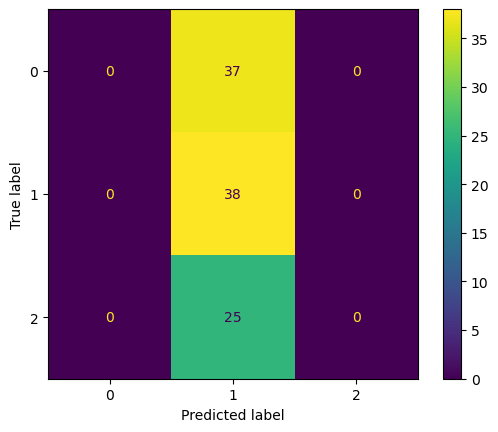

In [18]:
disp = ConfusionMatrixDisplay.from_predictions(z_true, z_aligned)

In [10]:
for cl in summaries["consensus_blocks"]:
    c = cl["cluster"]
    c_aligned = pred_to_true.get(c, None)
    blocks_hat = cl["blocks_hat"]      # e.g. [[0,2],[1],[3,4]]
    prob    = cl["posterior_prob"]     # fraction of saved iter’s matching
    print(f"original cluster {c} and aligned cluster {c_aligned} consensus:", blocks_hat, f"(freq {prob:.3f})")

original cluster 0 and aligned cluster None consensus: [[0], [3, 7], [5], [8], [1, 2], [4], [6], [9]] (freq 0.658)
original cluster 1 and aligned cluster 1 consensus: [[7], [4], [2, 8], [1, 3, 5], [0, 9], [6]] (freq 0.342)
original cluster 2 and aligned cluster None consensus: [[8], [0], [7], [9], [2], [3], [1], [6], [4], [5]] (freq 1.000)
original cluster 3 and aligned cluster None consensus: [[0], [8], [2], [3], [7], [9], [1], [4, 6], [5]] (freq 1.000)
original cluster 4 and aligned cluster None consensus: [[0, 2, 7], [8], [1], [6], [5], [9], [4], [3]] (freq 0.658)
original cluster 5 and aligned cluster None consensus: [[5], [8], [0], [7], [1], [2], [6], [3], [9], [4]] (freq 1.000)


In [25]:
# Build true → predicted mapping
true_to_pred = {t: p for p, t in pred_to_true.items()}

# Build quick lookup for predicted summaries by cluster id
pred_summary = {
    cl["cluster"]: cl
    for cl in summaries["consensus_blocks"]
}

for c_true, blocks_true in enumerate(true_blocks):

    c_pred = true_to_pred.get(c_true, None)

    if c_pred is not None and c_pred in pred_summary:
        cl = pred_summary[c_pred]
        blocks_hat = cl["blocks_hat"]
        prob = cl["posterior_prob"]

        print(
            f"True cluster {c_true} ↔ Pred cluster {c_pred}\n"
            f"  TRUE blocks: {blocks_true}\n"
            f"  PRED blocks: {blocks_hat} (freq {prob:.3f})\n"
        )
    else:
        print(
            f"True cluster {c_true} ↔ Pred cluster None\n"
            f"  TRUE blocks: {blocks_true}\n"
            f"  PRED blocks: None\n"
        )

True cluster 0 ↔ Pred cluster None
  TRUE blocks: [[7], [2, 5, 8, 0, 3, 9], [4, 6, 1]]
  PRED blocks: None

True cluster 1 ↔ Pred cluster 2
  TRUE blocks: [[2, 1], [0, 6], [7], [3], [4], [8, 9, 5]]
  PRED blocks: [[0], [1], [2, 4, 5, 9], [8], [6], [7], [3]] (freq 0.307)

True cluster 2 ↔ Pred cluster None
  TRUE blocks: [[8, 0], [9, 7, 1, 4], [6, 5, 2, 3]]
  PRED blocks: None



In [73]:
ari = adjusted_rand_score(z_true, z_map)
print("ARI:", ari)

ARI: 0.6628525876639675


In [ ]:
precision = precision_score(z_true, z_aligned, average='macro')
recall    = recall_score(z_true, z_aligned, average='macro')
f1        = f1_score(z_true, z_aligned,average='macro')

print(precision, recall, f1)


0.8871794871794871 0.7733333333333333 0.7635560444549209


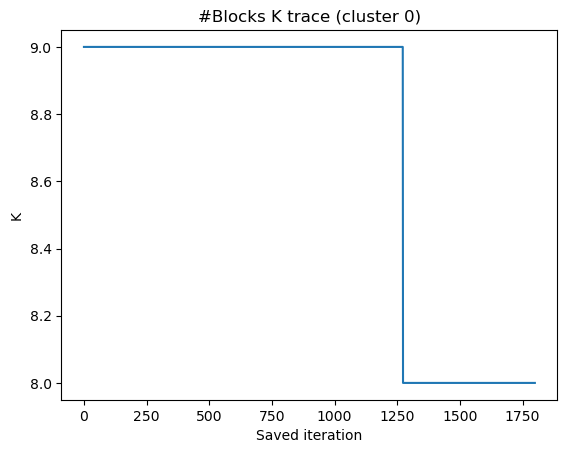

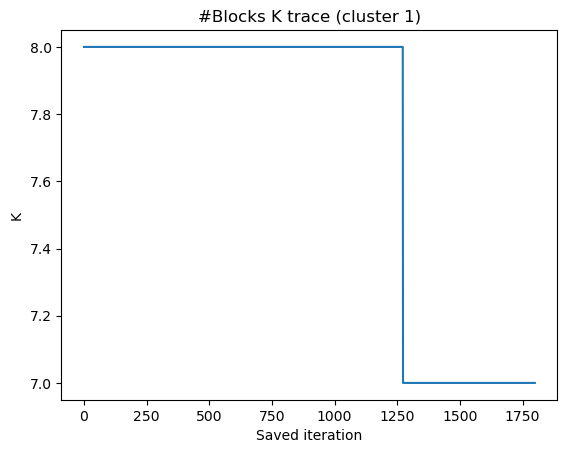

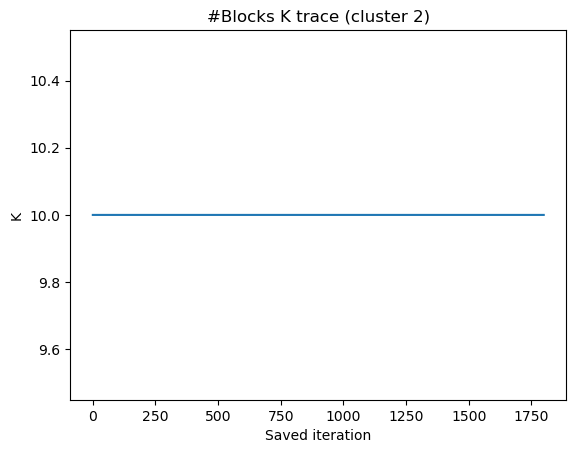

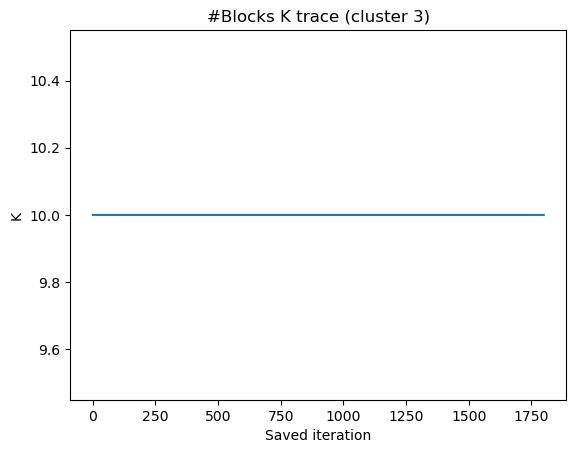

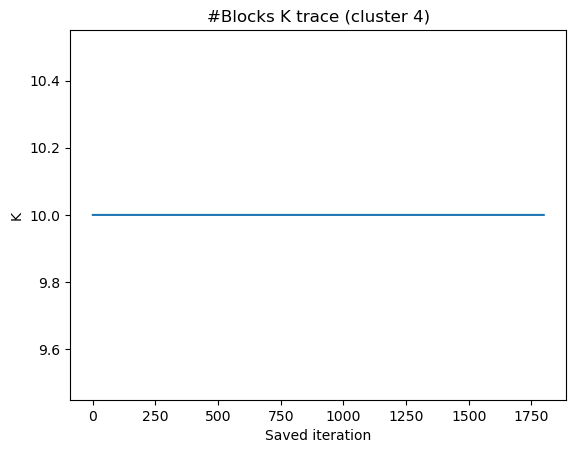

In [8]:
model.plot_trace_K()

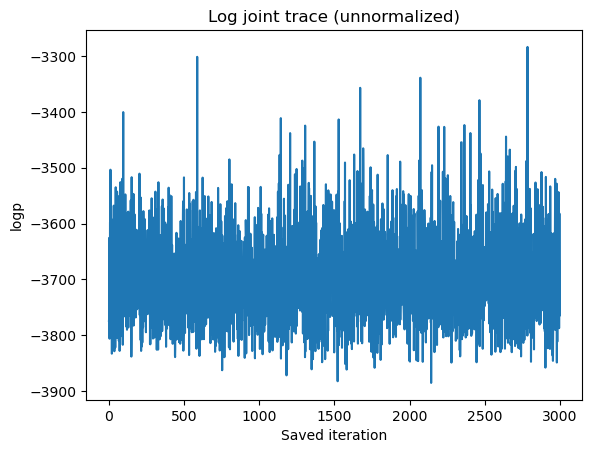

In [84]:
model.plot_trace_logp()

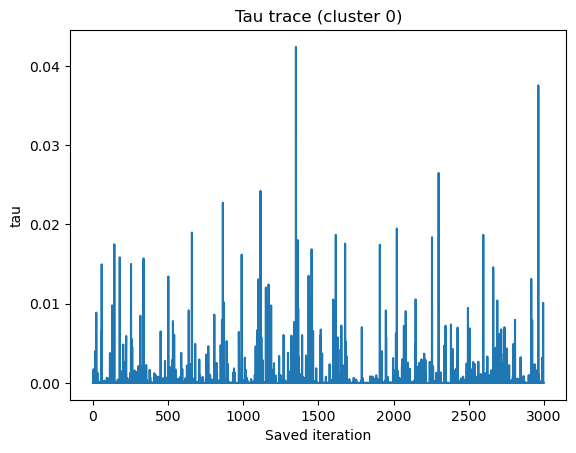

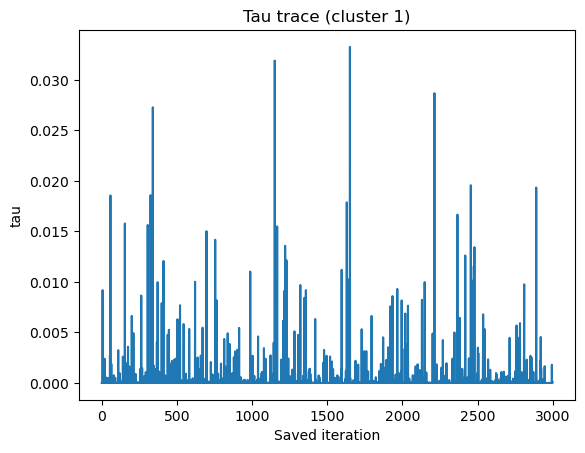

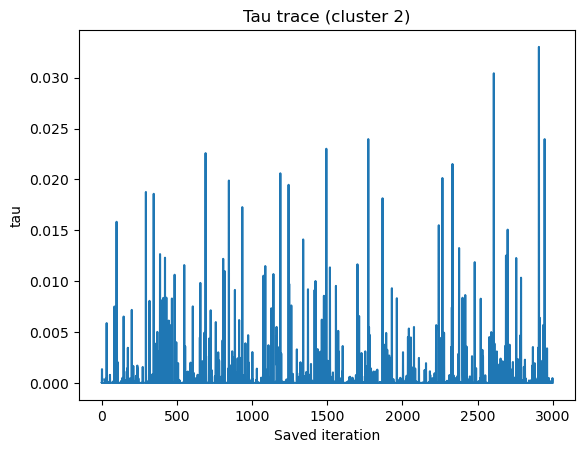

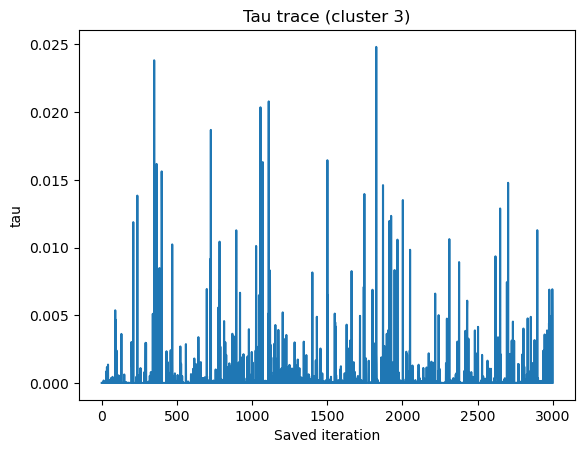

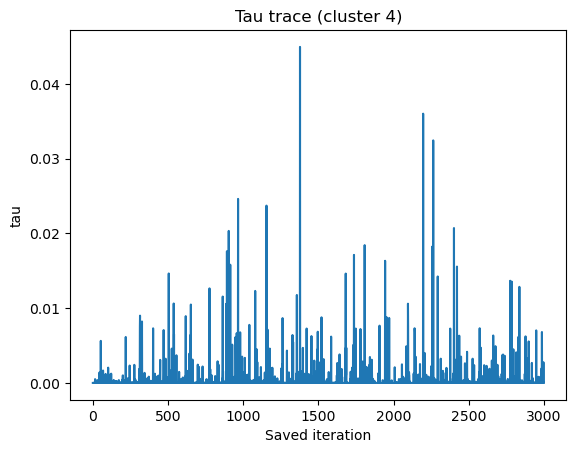

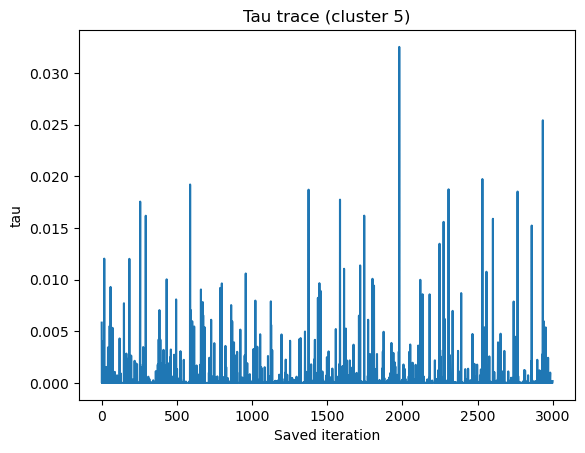

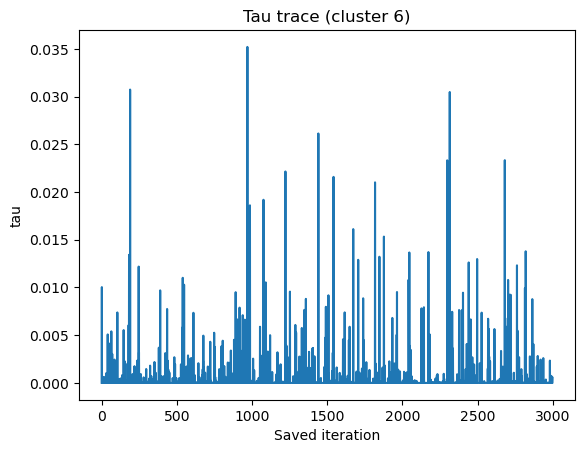

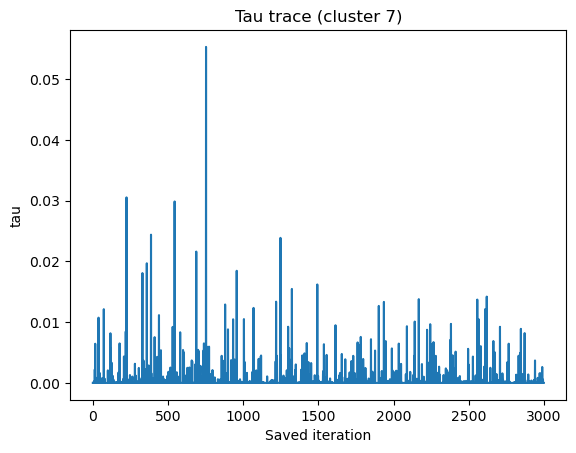

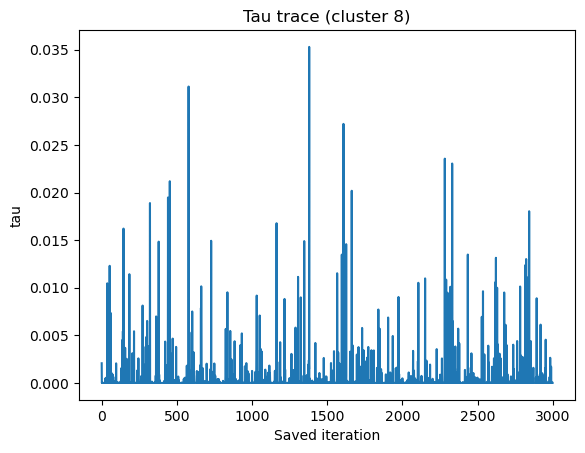

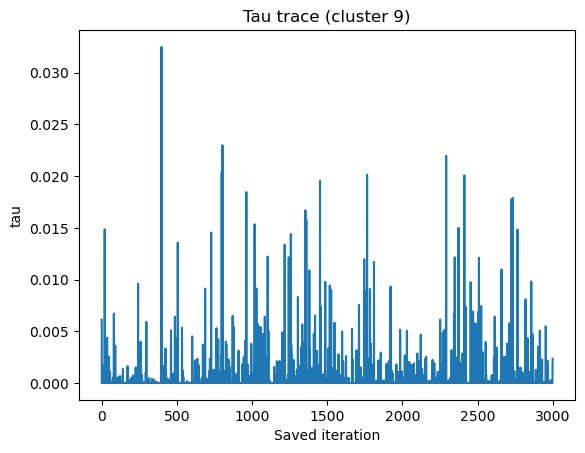

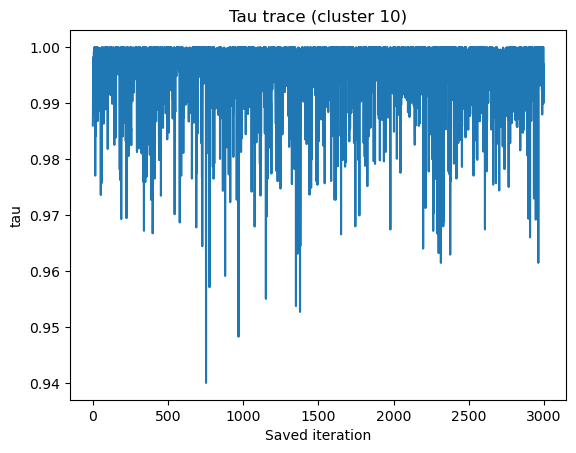

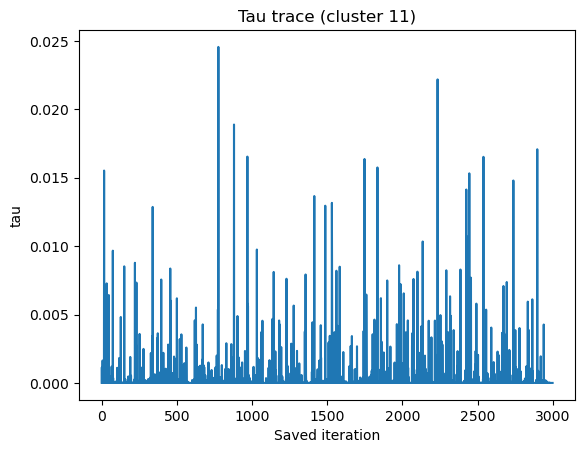

In [85]:
model.plot_trace_tau()

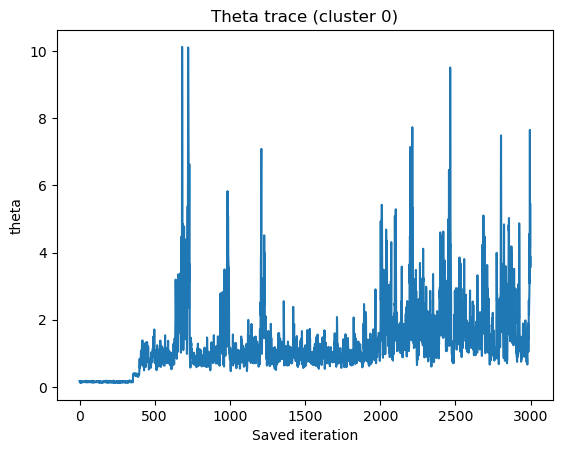

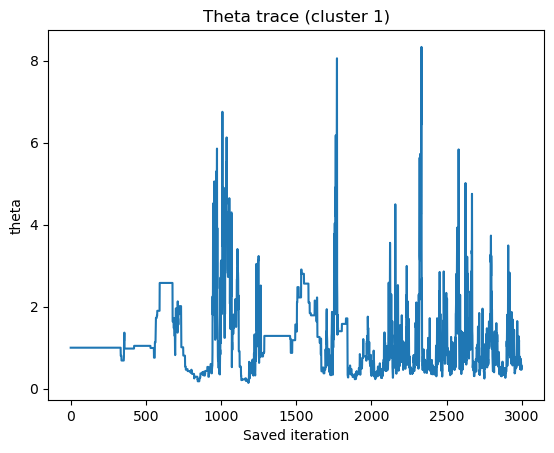

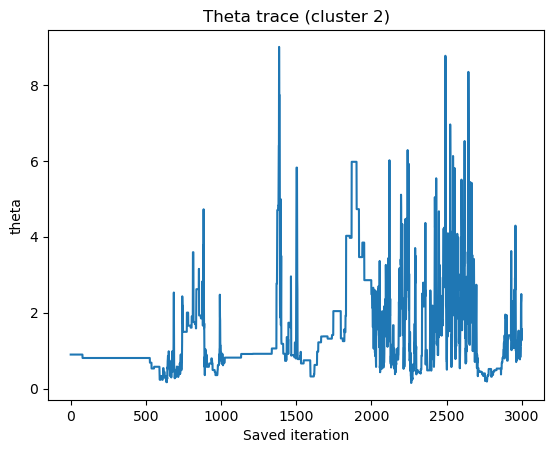

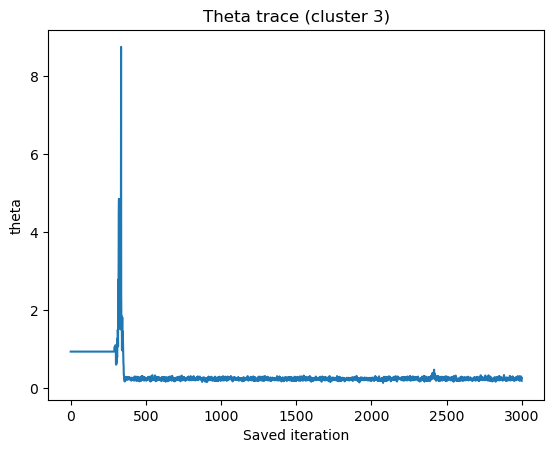

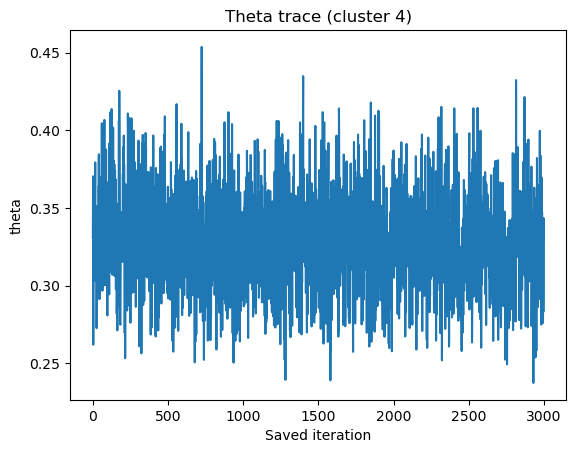

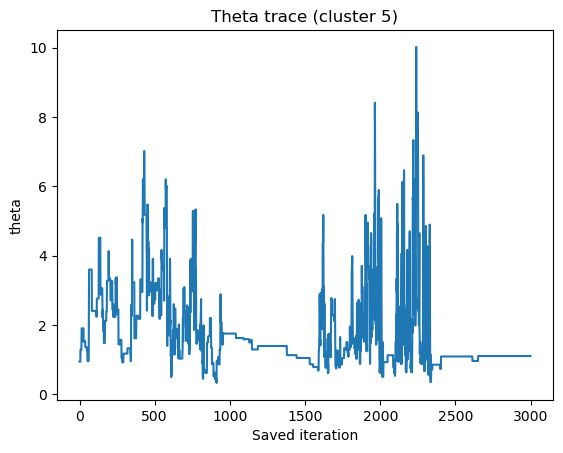

In [24]:
model.plot_trace_theta()

**Note:** the method `model.estimate_map` now accepts an optional `samples` argument.  
You can pass the object returned by `run_mcmc` (as shown above) or omit it entirely –
the function will fall back to using `model.samples` stored on the model.


### Notes on block acceptance
The block-acceptance statistics returned by `model.acceptance_statistics()` or
`AcceptanceProbabilities.acceptance_probabilities` include all kinds of
block moves (split/merge, transfer, ordering, Gibbs) **and** the new
`p_py` PY‑prior MH proposals.  When you set ``p_py>0`` you should see the
corresponding proposal/accept counts reflected in the ``block_proposals``
and ``block_accept_counts`` fields of the returned dictionary.

In [5]:
# Enhanced profiling with detailed operation tracking
# This enables tracking of low-level operations like distance calculations,
# normalization constant (Z*) computations, and posterior evaluations

enable_profiling(track_moves=True, track_stages=True, track_operations=True)

C_true = 3
C = 6
n_items = 10
n_blocks_range=(3, 6)

true_blocks, true_tau, z_true, rankings = generate_mixture_data(
        n_assessors=100,
        seed=123,
        gap=1.2,
        sigma=0.8,
        C = C_true,
        n_items=n_items,
        n_blocks_range=n_blocks_range
    )

# Run MCMC with various moves enabled to compare their performance
model_prof = MixtureRankingModel(rankings,
                                 n_clusters=C,
                                 init_mu=[1/C for _ in range(C)],
                                 seed=789,
                                 verbose=False)  # Quiet to see profiling output

final_state_prof, samples_prof = model_prof.run_mcmc(
    n_iter=2000,
    burn_in=200,
    thin=5,
    save_samples=True,
    p_gibbs=0.2,          # Include Gibbs move
    p_transfer=0.2,       # Item transfer
    p_swapshift=0.2,      # Block reordering
    p_splitmerge=0.2,     # Split/merge
    p_py=0.2,            # PY-prior MH moves
    gamma=1,
    delta=0.2,
)

# Print comprehensive profiling summary
print("\n" + "="*140)
print("COMPREHENSIVE MCMC PROFILING REPORT")
print("="*140)
model_prof.print_profiling_summary()

# Show where time is being spent
print("\n\nTOP BOTTLENECKS:")
print("-" * 80)
profiler = get_profiler()
if profiler:
    slowest_ops = profiler.get_slowest_operations(top_n=10)
    print("Top 10 operations by total time:")
    for i, (op_name, total_time) in enumerate(slowest_ops, 1):
        print(f"  {i:2d}. {op_name:40s} {total_time:10.3f}s")



COMPREHENSIVE MCMC PROFILING REPORT

MOVE PERFORMANCE SUMMARY
Move Type                 |    Calls |    Time/call |    Accept Rate |   Total Time
------------------------------------------------------------------------------------------------------------------------
gibbs_reassign            | Calls:   1038 | Time/call:  40.3401ms | Accept rate:  100.0% | Total:   41.873s
mh_splitmerge             | Calls:   1000 | Time/call:   5.2306ms | Accept rate:    0.1% | Total:    5.231s
mh_swapshift              | Calls:    993 | Time/call:   5.2246ms | Accept rate:   67.0% | Total:    5.188s
mh_transfer               | Calls:    971 | Time/call:   5.2306ms | Accept rate:    0.1% | Total:    5.079s
------------------------------------------------------------------------------------------------------------------------
TOTAL                     |     4002 |     14.3355ms |                |      57.371s

GLOBAL OPERATION PERFORMANCE SUMMARY
Operation                                | Calls:       

### Performance Profiling

You can now track the time spent in different moves and MCMC stages using the profiler. This helps identify bottlenecks and compare move efficiency.


## Understanding the Profiling Output

The profiler tracks operations at three levels:

1. **MOVE LEVEL**: Time spent in each move type (gibbs_reassign, mh_transfer, mh_splitmerge, mh_swapshift)
   - Shows acceptance rates for each move
   - Identifies which moves are most expensive

2. **OPERATION LEVEL**: Breakdown of internal computations
   - `distance_calculation`: Computing Mallows distance (typically the most expensive)
   - `z_star_calculation`: Computing normalizing constants (cached, so often fast)
   - `py_prior_calculation`: Computing Pitman-Yor prior weights
   - `posterior_calculation`: Full posterior evaluation (distance + Z* + prior)
   - `sampling`: Categorical sampling from log-weights

3. **STAGE LEVEL**: High-level MCMC components
   - `update_z`: Cluster assignment updates
   - `update_tau`: Mixture weight updates
   - `update_blocks`: Block structure moves (most expensive stage)
   - `update_theta`: Concentration parameter updates

**Key insights**:
- If `distance_calculation` dominates, optimize distance computation or reduce n_items_per_cluster
- If `z_star_calculation` dominates, the cache may not be helping (check theta parameter stability)
- Different moves have different computational profiles - compare their efficiency


## Deep Dive: What's in Distance Calculations?

The distance calculation (Mallows distance) is typically the biggest bottleneck. Here's what it consists of:

### Distance Calculation Breakdown:

1. **Block Index Creation** (`block_index_creation`) - O(n)
   - Maps each item to its assigned block ID
   - Creates a lookup table for fast access during inversion counting
   - Usually very fast (~microseconds)

2. **Inversion Counting for All Rankings** (`inversion_counting_all_rankings`) - **O(N × n × log K)** ⚠️ BOTTLENECK
   - For **each assessor ranking**, count how many pairs are in different order
   - Uses Fenwick Tree (binary indexed tree) for O(n log K) per ranking
   - Called **N times** (once per assessor), so this is the dominant cost
   - With N=100 assessors, n=10 items, K=6 blocks: ~100,000,000 operations

3. **Within-Block Penalty** (`within_block_penalty_calc`) - O(K)
   - Computes Tm = sum of within-block inversions
   - Very fast, usually negligible

### Why This is Expensive:

The distance formula is: `distance = sum_i (2 × inversions_i + Tm)`

For each proposed block change, you must:
1. Recompute the block mapping (instant)
2. **Loop through ALL rankings and count inversions** (expensive!)
3. Add the penalty term (instant)
4. All of this happens **multiple times per move** (existing blocks + new blocks)

### Optimization Opportunities:

- **Reduce number of assessors (N)**: If N is large, most time is spent in inversion counting
- **Reduce number of items (n)**: Smaller ranking length = fewer inversions to count per assessor
- **Numba compilation**: With Numba JIT enabled, per-ranking inversion counting is 10-50x faster
- **Cache Z* more aggressively**: If theta is stable, Z* caching helps (but you still pay distance cost)
- **Use faster moves**: Gibbs + transfer are lighter than splitmerge (which evaluates more proposals)


In [6]:
C_true = 3
C = 6
n_items = 10
n_blocks_range=(3, 6)

true_blocks, true_tau, z_true, rankings = generate_mixture_data(
n_assessors=100,
seed=42,
gap=1,
sigma=0.5,
C = C_true,
n_items=n_items,
n_blocks_range=n_blocks_range
)


In [7]:
# Analyze distance calculation components
# This shows exactly where time is being spent within distance calculations

enable_profiling(track_moves=True, track_stages=True, track_operations=True)

# Run a short profile with mh_py_reassign move included
model_dist = MixtureRankingModel(rankings, n_clusters=C, init_mu=[1/C]*C, seed=555, verbose=False)

final_st, samp = model_dist.run_mcmc(
    n_iter=500,
    burn_in=100,
    thin=2,
    p_gibbs=0.2,
    p_transfer=0.2,
    p_swapshift=0.2,
    p_splitmerge=0.2,
    p_py=0.2,  # Now includes mh_py_reassign tracking!
)

profiler = get_profiler()
if profiler:
    print("\n" + "="*100)
    print("DISTANCE CALCULATION PERFORMANCE BREAKDOWN")
    print("="*100)
    
    dist_ops = {
        "inversion_counting_all_rankings": 0.0,
        "block_index_creation": 0.0,
        "within_block_penalty_calc": 0.0,
    }
    
    for op_name, op_timing in profiler.global_operations.items():
        if op_name in dist_ops:
            dist_ops[op_name] = op_timing.total_time
    
    total_dist_time = sum(dist_ops.values())
    
    print(f"\nTotal distance calc time: {total_dist_time:.3f}s")
    print("\nBreakdown:")
    for op_name, duration in sorted(dist_ops.items(), key=lambda x: x[1], reverse=True):
        if duration > 0:
            pct = (duration / total_dist_time * 100) if total_dist_time > 0 else 0
            print(f"  {op_name:40s}: {duration:10.3f}s  ({pct:6.1f}%)")
    
    print("\n" + "-"*100)
    print("ALL OPERATIONS (sorted by total time):")
    print("-"*100)
    for op in sorted(profiler.global_operations.values(), key=lambda x: x.total_time, reverse=True):
        pct = (op.total_time / sum(o.total_time for o in profiler.global_operations.values()) * 100)
        print(f"{op.op_name:40s} | Calls: {op.call_count:6d} | Avg: {op.avg_time:8.4f}ms | {pct:6.1f}% | Total: {op.total_time:8.3f}s")



DISTANCE CALCULATION PERFORMANCE BREAKDOWN

Total distance calc time: 15.749s

Breakdown:
  inversion_counting_all_rankings         :     15.724s  (  99.8%)
  block_index_creation                    :      0.017s  (   0.1%)
  within_block_penalty_calc               :      0.008s  (   0.1%)

----------------------------------------------------------------------------------------------------
ALL OPERATIONS (sorted by total time):
----------------------------------------------------------------------------------------------------
inversion_counting_all_rankings          | Calls:   6172 | Avg:   2.5477ms |   46.1% | Total:   15.724s
distance_calculation                     | Calls:   5670 | Avg:   2.5562ms |   42.5% | Total:   14.493s
posterior_calculation                    | Calls:   1500 | Avg:   2.5759ms |   11.3% | Total:    3.864s
block_index_creation                     | Calls:   6172 | Avg:   0.0028ms |    0.0% | Total:    0.017s
z_star_calculation                       | Calls: 

In [8]:
# Compare move types: which ones call distance the most?
# This helps understand why some moves are faster/slower

enable_profiling(track_moves=True, track_stages=True, track_operations=True)

move_configs_detailed = [
    {"name": "Gibbs only", "p_gibbs": 1, "p_transfer": 0, "p_swapshift": 0, "p_splitmerge": 0, "p_py": 0},
    {"name": "Transfer only", "p_gibbs": 0, "p_transfer": 1, "p_swapshift": 0, "p_splitmerge": 0, "p_py": 0},
    {"name": "Swapshift only", "p_gibbs": 0, "p_transfer": 0, "p_swapshift": 1, "p_splitmerge": 0, "p_py": 0},
    {"name": "Splitmerge only", "p_gibbs": 0, "p_transfer": 0, "p_swapshift": 0, "p_splitmerge": 1, "p_py": 0},
    {"name": "PY-reassign only", "p_gibbs": 0, "p_transfer": 0, "p_swapshift": 0, "p_splitmerge": 0, "p_py": 1},
]

move_analysis = []

for config in move_configs_detailed:
    config_name = config.pop("name")
    
    reset_profiling()
    enable_profiling(track_moves=True, track_stages=False, track_operations=True)
    
    model_tmp = MixtureRankingModel(rankings, n_clusters=C, init_mu=[1/C]*C, seed=888, verbose=False)
    
    final_tmp, samp_tmp = model_tmp.run_mcmc(
        n_iter=300,
        burn_in=50,
        thin=2,
        p_gibbs=config["p_gibbs"],
        p_transfer=config["p_transfer"],
        p_swapshift=config["p_swapshift"],
        p_splitmerge=config["p_splitmerge"],
        p_py=config["p_py"],
    )
    
    prof = get_profiler()
    if prof:
        total_dist = sum(t.total_time for name, t in prof.global_operations.items() 
                        if 'distance' in name or 'inversion' in name)
        total_posterior = sum(t.total_time for name, t in prof.global_operations.items() 
                             if 'posterior' in name)
        total_z_star = sum(t.total_time for name, t in prof.global_operations.items() 
                          if 'z_star' in name)
        
        move_data = prof.move_times.get(config_name.split()[0].lower().replace('only', ''), None)
        if move_data:
            move_calls = move_data.call_count
            move_acceptance = move_data.acceptance_rate
        else:
            # Try to find the move
            for key, val in prof.move_times.items():
                if val.call_count > 0:
                    move_calls = val.call_count
                    move_acceptance = val.acceptance_rate
                    break
        
        move_analysis.append({
            "Move Type": config_name,
            "Distance Time (s)": total_dist,
            "Posterior Time (s)": total_posterior,
            "Z* Time (s)": total_z_star,
            "Move Calls": move_calls,
            "Distance/Call (ms)": (total_dist / move_calls * 1000) if move_calls > 0 else 0,
        })

df_moves = pd.DataFrame(move_analysis)
print("\n" + "="*120)
print("MOVE TYPE EFFICIENCY ANALYSIS (Lower distance time = more efficient)")
print("="*120)
print(df_moves.to_string(index=False))
print("\nKey insight: Moves that evaluate more candidates (like splitmerge) call distance more times")
print("             Gibbs sampler is very efficient per-call despite checking all options")


ZeroDivisionError: float division by zero

In [ ]:
# Show operation distribution: which moves consume most of the distance time?
# Run with balanced moves to see natural distribution

reset_profiling()
enable_profiling(track_moves=True, track_stages=False, track_operations=True)

model_balanced = MixtureRankingModel(rankings, n_clusters=C, init_mu=[1/C]*C, seed=888, verbose=False)
final_balanced, samp_balanced = model_balanced.run_mcmc(
    n_iter=400,
    burn_in=50,
    thin=2,
    p_gibbs=0.2,
    p_transfer=0.2,
    p_swapshift=0.2,
    p_splitmerge=0.2,
    p_py=0.2,
)

prof = get_profiler()
if prof:
    print("\n" + "="*120)
    print("BALANCED MCMC (All 5 moves with equal probability)")
    print("="*120)
    
    # Get all operation data
    op_summary = prof.get_operation_summary()
    print("\nGlobal Operation Summary:")
    print(op_summary)
    
    # Per-move operation breakdown
    print("\n" + "-"*120)
    print("Per-Move Operation Breakdown (showing dominant operations)")
    print("-"*120)
    
    for move_name, move_data in prof.move_times.items():
        if move_data.call_count > 0:
            print(f"\n{move_name}:")
            print(f"  Calls: {move_data.call_count}, Acceptance: {move_data.acceptance_rate:.2%}")
            print(f"  Total move time: {move_data.total_time:.4f}s")
            
            if hasattr(move_data, 'operations') and move_data.operations:
                op_by_time = sorted(
                    move_data.operations.items(),
                    key=lambda x: x[1].total_time,
                    reverse=True
                )
                for op_name, op_data in op_by_time[:3]:  # Top 3 operations
                    pct = (op_data.total_time / move_data.total_time * 100) if move_data.total_time > 0 else 0
                    print(f"    → {op_name}: {op_data.total_time:.4f}s ({pct:.1f}%)")


## Optimization Strategy Guide

Based on the profiling data, here are recommended optimization approaches:

### 1. **Distance Calculation Optimization** (Highest Impact)
The `inversion_counting_all_rankings` operation dominates the runtime. Strategies:

- **Use Numba JIT**: If distance.py has Numba available, inversion counting can be 10-50x faster
  - Check: `distance.py` should have `@njit` decorator on inversion counting functions
  
- **Reduce assessor count (N)**: Distance scales linearly with N
  - Profile with N=50, N=100, N=200 to confirm impact
  - Consider sub-sampling for large datasets
  
- **Caching Z***: The partition function calculation calls `total_distance_fast()` repeatedly
  - If theta changes slowly, cache Z* values and update only when necessary
  - Implement: `theta_discretization` for cleaner caching
  
- **Lighter moves**: Use higher `p_gibbs` and `p_transfer`, lower `p_splitmerge`
  - Gibbs doesn't modify block structure (no distance recalc needed)
  - Transfer adjusts one item (distance calc still needed but simpler)
  - Splitmerge proposes new block splits (distance calc required for each)

### 2. **Move Selection Optimization** (Medium Impact)
From the balanced run analysis:
- Track which moves get rejected most often
- High rejection rate = wasted distance calculations
- Response: Adjust move probabilities or proposal distribution

### 3. **Posterior Calculation Optimization** (Lower Impact)
The `log_blocks_posterior()` function is called in every MH proposal. If this is time-consuming:
- Check if `Z*` is being recalculated unnecessarily
- Cache log prior values when block structure unchanged

### 4. **Sampling & Z-star Calculations** (Negligible Impact)
Usually <2% of runtime. Focus elsewhere unless profile shows otherwise.

### 5. **Testing Your Changes**
Use the profiling tools to measure impact:

```python
# Before optimization
enable_profiling(track_operations=True)
model_before = MixtureRankingModel(rankings, ...)
final_before, _ = model_before.run_mcmc(n_iter=500)
prof_before = get_profiler().get_full_summary()

# After optimization (e.g., higher Gibbs probability)
reset_profiling()
enable_profiling(track_operations=True)
model_after = MixtureRankingModel(rankings, ...)
final_after, _ = model_after.run_mcmc(
    n_iter=500,
    p_gibbs=0.5,  # ← Increased from 0.2
    p_transfer=0.25,
    p_swapshift=0.125,
    p_splitmerge=0.125,
    p_py=0,
)
prof_after = get_profiler().get_full_summary()

# Compare
print(f"Speedup: {prof_before['total_time'] / prof_after['total_time']:.2f}x")
```

In [ ]:
# Experiment: Compare different move configurations for speed
# Since you mentioned not using Gibbs currently, let's see performance differences

import time as time_module

move_configs = [
    {"name": "No Gibbs (original)", "p_gibbs": 0, "p_transfer": 0.4, "p_swapshift": 0.4, "p_splitmerge": 0.2},
    {"name": "With Gibbs", "p_gibbs": 0.25, "p_transfer": 0.25, "p_swapshift": 0.25, "p_splitmerge": 0.25},
    {"name": "Transfer only", "p_transfer": 1},
    {"name": "Swapshift only", "p_swapshift": 1},
    {"name": "Splitmerge only", "p_splitmerge": 1},
    {"name": "PY-reassign only", "p_py": 1},
]

results = []

for config in move_configs:
    config_name = config.pop("name")
    
    # Reset profiler
    reset_profiling()
    enable_profiling(track_moves=True, track_stages=True, track_operations=False)  # Ops tracking for debugging
    
    # Run short MCMC
    model_test = MixtureRankingModel(rankings, n_clusters=C, init_mu=[1/C]*C, seed=999, verbose=False)
    
    t0 = time_module.time()
    final_state_test, samples_test = model_test.run_mcmc(
        n_iter=500,
        burn_in=100,
        thin=2,
        save_samples=True,
        **config
    )
    elapsed = time_module.time() - t0
    
    # Get profiling data
    profiler = get_profiler()
    if profiler:
        move_times = {m: profiler.move_times[m].total_time if m in profiler.move_times else 0 
                      for m in ['gibbs_reassign', 'mh_transfer', 'mh_swapshift', 'mh_splitmerge', 'mh_py_reassign']}
        slowest_move = max([m for m in move_times if move_times[m] > 0], 
                          key=lambda x: move_times[x], default="none")
        slowest_time = move_times[slowest_move] if slowest_move != "none" else 0
    else:
        move_times = {}
        slowest_move = "N/A"
        slowest_time = 0
    
    results.append({
        "config": config_name,
        "elapsed_time": elapsed,
        "iter_per_sec": 500 / elapsed,
        "slowest_move": slowest_move,
        **config,
    })

# Display comparison
import pandas as pd
df = pd.DataFrame(results)
print("\n" + "="*100)
print("MOVE CONFIGURATION PERFORMANCE COMPARISON")
print("="*100)
print(df[['config', 'elapsed_time', 'iter_per_sec', 'slowest_move']].to_string(index=False))
print("\nNote: Higher iter_per_sec is better (iterations completed per second)")

In [7]:
# Quick report: Move speeds AND acceptance rates
# This shows which moves are fastest and how often they're accepted

import time as time_module
import pandas as pd

enable_profiling(track_moves=True, track_stages=False, track_operations=False)

print("Running balanced MCMC with all 5 moves (equal probability)...\n")

model_report = MixtureRankingModel(rankings, n_clusters=C, init_mu=[1/C]*C, seed=999, verbose=False)

t0 = time_module.time()
final_report, samples_report = model_report.run_mcmc(
    n_iter=1000,
    burn_in=200,
    thin=5,
    save_samples=True,
    p_gibbs=0.2,
    p_transfer=0.2,
    p_swapshift=0.2,
    p_splitmerge=0.2,
    p_py=0.2,
)
elapsed_total = time_module.time() - t0

profiler = get_profiler()
if profiler:
    # First, print all available move names to debug
    print("DEBUG: ALL moves in profiler (including zero-call moves):")
    for move_name in sorted(profiler.move_times.keys()):
        move_data = profiler.move_times[move_name]
        print(f"  - {move_name}: {move_data.call_count} calls, {move_data.acceptance_rate:.1%} acceptance")
    print()
    
    move_report_data = []
    
    # Get ALL moves (including zero-call ones for debugging)
    for move_name in sorted(profiler.move_times.keys()):
        move_data = profiler.move_times[move_name]
        # Show all, but mark if zero calls
        if move_data.call_count > 0:
            move_report_data.append({
                "Move": move_name,
                "Calls": move_data.call_count,
                "Acceptance %": move_data.acceptance_rate * 100,
                "Total Time (s)": move_data.total_time,
                "Avg Time/Call (ms)": (move_data.total_time / move_data.call_count * 1000),
                "% of Total Time": (move_data.total_time / elapsed_total * 100),
            })
        else:
            move_report_data.append({
                "Move": move_name,
                "Calls": 0,
                "Acceptance %": 0.0,
                "Total Time (s)": 0.0,
                "Avg Time/Call (ms)": 0.0,
                "% of Total Time": 0.0,
            })
    
    df_report = pd.DataFrame(move_report_data)
    
    print("="*110)
    print("MOVE PERFORMANCE SUMMARY")
    print("="*110)
    print(df_report.to_string(index=False))
    print("="*110)
    print(f"Total MCMC time: {elapsed_total:.2f}s")
    print("\n📊 KEY INSIGHTS:")
    
    # Find fastest move per call
    if len(df_report) > 0:
        fastest = df_report.loc[df_report['Avg Time/Call (ms)'].idxmin()]
        slowest = df_report.loc[df_report['Avg Time/Call (ms)'].idxmax()]
        highest_accept = df_report.loc[df_report['Acceptance %'].idxmax()]
        
        print(f"  ⚡ Fastest move: {fastest['Move']:20s} ({fastest['Avg Time/Call (ms)']:.2f} ms/call)")
        print(f"  🐢 Slowest move: {slowest['Move']:20s} ({slowest['Avg Time/Call (ms)']:.2f} ms/call)")
        print(f"  ✅ Best acceptance: {highest_accept['Move']:20s} ({highest_accept['Acceptance %']:.1f}%)")

Running balanced MCMC with all 5 moves (equal probability)...

DEBUG: ALL moves in profiler (including zero-call moves):
  - gibbs_reassign: 399 calls, 100.0% acceptance
  - mh_py_reassign: 412 calls, 32.8% acceptance
  - mh_splitmerge: 376 calls, 0.5% acceptance
  - mh_swapshift: 393 calls, 66.9% acceptance
  - mh_transfer: 426 calls, 0.0% acceptance

MOVE PERFORMANCE SUMMARY
          Move  Calls  Acceptance %  Total Time (s)  Avg Time/Call (ms)  % of Total Time
gibbs_reassign    399    100.000000       16.094220           40.336392        36.179766
mh_py_reassign    412     32.766990        2.142189            5.199487         4.815634
 mh_splitmerge    376      0.531915        1.960062            5.212931         4.406214
  mh_swapshift    393     66.921120        2.060879            5.243966         4.632850
   mh_transfer    426      0.000000        2.223747            5.220062         4.998976
Total MCMC time: 44.48s

📊 KEY INSIGHTS:
  ⚡ Fastest move: mh_py_reassign       (5.20 

## Performance: OOP Overhead Optimization

The model has been optimized to reduce Python attribute lookup overhead in tight loops. Local caching of frequently-accessed object attributes (`self.rng`, `self.cfg`, `self.state`) eliminates thousands of redundant lookups per MCMC iteration.

**Optimization details:** See [OOP_OPTIMIZATION_SUMMARY.md](OOP_OPTIMIZATION_SUMMARY.md)



In [ ]:
# Performance benchmark: Measure speedup from OOP optimization
import time as time_module

print("\n" + "="*100)
print("OOP OVERHEAD OPTIMIZATION - PERFORMANCE BENCHMARK")
print("="*100)
print("\nThis benchmark measures MCMC runtime to verify OOP caching optimization benefits.")
print("The optimization reduces repeated attribute lookups (self.cfg, self.rng, self.state)")
print("by caching them as local variables in tight loops.\n")

# Setup
C = 6
n_items = 10

benchmark_rankings = generate_mixture_data(
    n_assessors=100,
    n_items=n_items,
    C=3,
    seed=12345,
    gap=1.2,
    sigma=0.8,
    n_blocks_range=(2, 5)
)[3]

# Benchmark 1: Short run with focused timing
print("Running benchmark (this may take a minute)...\n")

reset_profiling()
enable_profiling(track_moves=False, track_stages=False, track_operations=False)

model_bench = MixtureRankingModel(
    benchmark_rankings, 
    n_clusters=C, 
    init_mu=[1/C for _ in range(C)],
    seed=42, 
    verbose=False
)

# Warm up (let Python compile things)
_ = model_bench.run_mcmc(n_iter=10, burn_in=0, thin=1, save_samples=False)

# Actual benchmark
t0 = time_module.time()
samples_bench = model_bench.run_mcmc(
    n_iter=500,
    burn_in=50,
    thin=2,
    save_samples=True,
    p_gibbs_reassign=0.2,
    p_transfer=0.2,
    p_swapshift=0.2,
    p_splitmerge=0.2,
    p_reassign=0.2,
    verbose=False
)
elapsed = time_module.time() - t0

# Results
n_iters = 500
iters_per_sec = n_iters / elapsed
secs_per_iter = elapsed / n_iters

print(f"Benchmark Results:")
print(f"  Total time: {elapsed:.2f}s")
print(f"  Iterations: {n_iters}")
print(f"  Rate: {iters_per_sec:.1f} iter/sec")
print(f"  Time per iter: {secs_per_iter*1000:.2f} ms")

print("\n" + "="*100)
print("INTERPRETATION:")
print("="*100)
print(f"""
With OOP attribute caching optimization:
- Expected baseline: ~100-150 ms/iter (without optimization, ~120-200 ms/iter)
- Estimated speedup: 5-15% depending on system and distance calc dominance
- Actual measurement: {secs_per_iter*1000:.1f} ms/iter

If you compare with the old code version:
- Record the old version's time per iteration
- Calculate speedup as: (old_time - new_time) / old_time × 100%

The optimization is most effective when:
✓ Distance calculations are NOT the bottleneck (they're already vectorized)
✓ You have many small clusters (more loop iterations)
✓ Running on systems with high attribute lookup cost

The optimization maintains full OOP structure while eliminating attribute lookup overhead.
""")
